In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("Orders_with_issues.csv")

print(df.head())
#Summary
print(df.info())

   OrderID CustomerID   OrderDate ShippedDate        ShippingCost ShipCountry  \
0   1000.0       C001  2025-05-17  2025-07-30  -57.25454602444980     Germany   
1   1001.0       C002  2025-01-26  2025-07-30              320.61      Canada   
2   1002.0       C003  2025-03-08  2025-07-30              165.17      Canada   
3   1003.0       C004  2025-03-24  2025-07-30               12.55     Germany   
4   1004.0       C005  2025-04-15  2025-07-30              186.36      Canada   

    ShipCity                 ShippingCompany  
0    Hamburg  Kiwilytics Goods Shipping LLC.  
1   Montreal                   UPS Worldwide  
2  Vancouver                 FedEx Logistics  
3     Munich            Aramex International  
4  Vancouver                 FedEx Logistics  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          239 non-null 

In [4]:
#Check missing values
print(df.isna().sum)

<bound method DataFrame.sum of      OrderID  CustomerID  OrderDate  ShippedDate  ShippingCost  ShipCountry  \
0      False       False      False        False         False        False   
1      False       False      False        False         False        False   
2      False       False      False        False         False        False   
3      False       False      False        False         False        False   
4      False       False      False        False         False        False   
..       ...         ...        ...          ...           ...          ...   
240    False       False      False        False         False        False   
241    False       False      False        False          True        False   
242    False       False      False        False         False        False   
243    False       False      False        False         False        False   
244    False       False      False        False         False        False   

     ShipCity  Shipp

In [ ]:
print("Unique Shipping Companies: ")
print(df["ShipCountry"].value_counts())

Unique Shipping Companies: 
ShipCountry
UK           56
USA          49
Canada       45
Egypt        41
Germany      38
Palestine    16
Name: count, dtype: int64


In [ ]:
# Convert dates To DateTime
df["OrderDate"] = pd.to_datetime(df["OrderDate"],errors="coerce")
df["ShippedDate"] = pd.to_datetime(df["ShippedDate"],errors="coerce")
df["ShippingCost"] = pd.to_numeric(df["ShippingCost"],errors="coerce")

#Clean order_id
df['OrderID'] = pd.to_numeric(df["OrderID"],errors="coerce")
df.loc[df['OrderID']<0,'OrderID']=np.nan

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          239 non-null    float64       
 1   CustomerID       240 non-null    object        
 2   OrderDate        226 non-null    datetime64[ns]
 3   ShippedDate      211 non-null    datetime64[ns]
 4   ShippingCost     230 non-null    float64       
 5   ShipCountry      245 non-null    object        
 6   ShipCity         241 non-null    object        
 7   ShippingCompany  245 non-null    object        
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 15.4+ KB


In [ ]:
# Handle nulls
df["OrderID"] = df["OrderID"].ffill()
df['CustomerID'] = df["CustomerID"].fillna('Unknown')
df['ShipCity'] = df["ShipCity"].fillna('Unspecified')


# Standardize names 
df["ShipCountry"] = df["ShipCountry"].str.strip().str.title()
df["ShipCity"] = df["ShipCity"].str.strip().str.title()
df["ShippingCompany"] = df["ShippingCompany"].str.strip()

# Fix specific cases
df.loc[df["ShippingCompany"].str.contains("Kiwilytics Goods Shipping Llc.", na=False),"ShippingCompany"]= "Kiwilytics" 
df.loc[df["ShippingCompany"].str.contains("Kiwilytics Goods Shipping LLC.", na=False),"ShippingCompany"]= "Kiwilytics" 
df.loc[df["ShipCity"].str.contains("Paris1", na=False),"ShipCity"]= "Paris" 

In [9]:
df.head()

,OrderID,CustomerID,OrderDate,ShippedDate,ShippingCost,ShipCountry,ShipCity,ShippingCompany
0,1000.0,C001,2025-05-17,2025-07-30,-57.254546,Germany,Hamburg,Kiwilytics
1,1001.0,C002,2025-01-26,2025-07-30,320.610000,Canada,Montreal,UPS Worldwide
2,1002.0,C003,2025-03-08,2025-07-30,165.170000,Canada,Vancouver,FedEx Logistics
3,1003.0,C004,2025-03-24,2025-07-30,12.550000,Germany,Munich,Aramex International
4,1004.0,C005,2025-04-15,2025-07-30,186.360000,Canada,Vancouver,FedEx Logistics


In [10]:
# Days between order and shipment
df['DeliveryDays'] = (df['ShippedDate'] - df['OrderDate']).dt.days

# Flags
def get_status(x):
    if pd.isna(x):
        return "Unknown"
    elif x > 15:
        return "Late"
    else:
        return "OnTime"

df['DeliveryStatus'] = df['DeliveryDays'].apply(get_status)
df.head(15)

,OrderID,CustomerID,OrderDate,ShippedDate,ShippingCost,ShipCountry,ShipCity,ShippingCompany,DeliveryDays,DeliveryStatus
0,1000.0,C001,2025-05-17,2025-07-30,-57.254546,Germany,Hamburg,Kiwilytics,74.0,Late
1,1001.0,C002,2025-01-26,2025-07-30,320.610000,Canada,Montreal,UPS Worldwide,185.0,Late
2,1002.0,C003,2025-03-08,2025-07-30,165.170000,Canada,Vancouver,FedEx Logistics,144.0,Late
3,1003.0,C004,2025-03-24,2025-07-30,12.550000,Germany,Munich,Aramex International,128.0,Late
4,1004.0,C005,2025-04-15,2025-07-30,186.360000,Canada,Vancouver,FedEx Logistics,106.0,Late
5,1005.0,C006,2024-12-24,2025-07-30,74.930000,Usa,New York,UPS Worldwide,218.0,Late
6,1006.0,C007,NaT,2025-07-30,229.930000,Usa,Los Angeles,Aramex International,NaN,Unknown
7,1007.0,C008,2024-08-10,2025-07-30,209.940000,Germany,Berlin,Aramex International,354.0,Late
8,1008.0,C009,2025-02-06,2025-07-30,NaN,Usa,Houston,DHL Express,174.0,Late
9,1009.0,C010,NaT,2025-07-30,394.370000,Usa,Chicago,Kiwilytics,NaN,Unknown


In [11]:
# Grouping examples
avg_shipping_company = df.groupby("ShippingCompany")['ShippingCost'].mean()
print(avg_shipping_company)

ShippingCompany
Aramex International    240.455949
DHL Express             226.637255
FedEx Logistics         229.533269
Kiwilytics              227.695936
UPS Worldwide           249.268272
Name: ShippingCost, dtype: float64


In [12]:
df.to_csv("cleaned_orders_final.csv",index=False)

#Final summary
print("\n Final Dataset Snapshot: ")
print(df.head())

print("\n📈 Delivery Status Breakdown:")
print(df['DeliveryStatus'].value_counts())

print("\n Order by City: ")
print(df["ShipCountry"].value_counts())   #.value_counts()  .

print("\n Order by Country: ")
print(df["ShipCity"].value_counts())

print("\nTop 3 Shipping Companies: ")
print(df["ShippingCompany"].value_counts().head(3))


 Final Dataset Snapshot: 
   OrderID CustomerID  OrderDate ShippedDate  ShippingCost ShipCountry  \
0   1000.0       C001 2025-05-17  2025-07-30    -57.254546     Germany   
1   1001.0       C002 2025-01-26  2025-07-30    320.610000      Canada   
2   1002.0       C003 2025-03-08  2025-07-30    165.170000      Canada   
3   1003.0       C004 2025-03-24  2025-07-30     12.550000     Germany   
4   1004.0       C005 2025-04-15  2025-07-30    186.360000      Canada   

    ShipCity       ShippingCompany  DeliveryDays DeliveryStatus  
0    Hamburg            Kiwilytics          74.0           Late  
1   Montreal         UPS Worldwide         185.0           Late  
2  Vancouver       FedEx Logistics         144.0           Late  
3     Munich  Aramex International         128.0           Late  
4  Vancouver       FedEx Logistics         106.0           Late  

📈 Delivery Status Breakdown:
DeliveryStatus
Late       190
Unknown     50
OnTime       5
Name: count, dtype: int64

 Order by City:

### Matplotlib

In [13]:
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_orders_final.csv")
df.head()

,OrderID,CustomerID,OrderDate,ShippedDate,ShippingCost,ShipCountry,ShipCity,ShippingCompany,DeliveryDays,DeliveryStatus
0,1000.0,C001,2025-05-17,2025-07-30,-57.254546,Germany,Hamburg,Kiwilytics,74.0,Late
1,1001.0,C002,2025-01-26,2025-07-30,320.610000,Canada,Montreal,UPS Worldwide,185.0,Late
2,1002.0,C003,2025-03-08,2025-07-30,165.170000,Canada,Vancouver,FedEx Logistics,144.0,Late
3,1003.0,C004,2025-03-24,2025-07-30,12.550000,Germany,Munich,Aramex International,128.0,Late
4,1004.0,C005,2025-04-15,2025-07-30,186.360000,Canada,Vancouver,FedEx Logistics,106.0,Late


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          245 non-null    float64
 1   CustomerID       245 non-null    object 
 2   OrderDate        226 non-null    object 
 3   ShippedDate      211 non-null    object 
 4   ShippingCost     230 non-null    float64
 5   ShipCountry      245 non-null    object 
 6   ShipCity         245 non-null    object 
 7   ShippingCompany  245 non-null    object 
 8   DeliveryDays     195 non-null    float64
 9   DeliveryStatus   245 non-null    object 
dtypes: float64(3), object(7)
memory usage: 19.3+ KB


In [15]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['ShippedDate'] = pd.to_datetime(df['ShippedDate'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          245 non-null    float64       
 1   CustomerID       245 non-null    object        
 2   OrderDate        226 non-null    datetime64[ns]
 3   ShippedDate      211 non-null    datetime64[ns]
 4   ShippingCost     230 non-null    float64       
 5   ShipCountry      245 non-null    object        
 6   ShipCity         245 non-null    object        
 7   ShippingCompany  245 non-null    object        
 8   DeliveryDays     195 non-null    float64       
 9   DeliveryStatus   245 non-null    object        
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 19.3+ KB


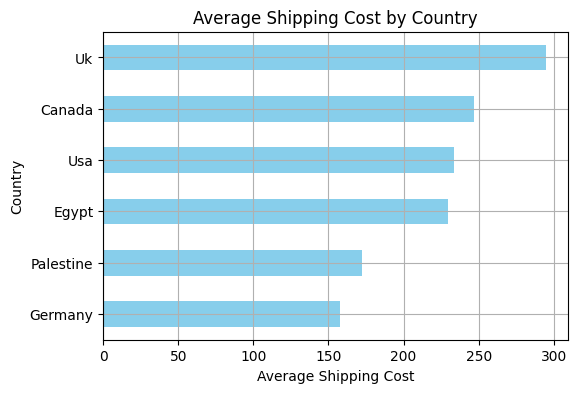

In [17]:
# Visualization 1: Shipping Cost by Country

# set the figure size for better readability  اضبط حجم الشكل لتحسين إمكانية القراءة
plt.figure(figsize=(6,4))


df.groupby("ShipCountry")["ShippingCost"].mean().sort_values().plot(kind="barh",color="skyblue")

# Set the title of the plot 
plt.title("Average Shipping Cost by Country")

# Label the X and Y axes
plt.xlabel("Average Shipping Cost")
plt.ylabel("Country")

# Show grid lines to improve readability
plt.grid()

plt.show()

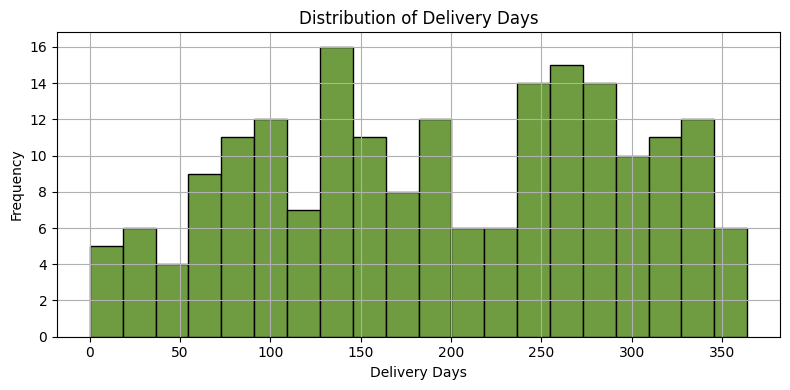

In [18]:
# Visualization 2: Delivery Days Distribution
plt.figure(figsize=(8,4))

df["DeliveryDays"].dropna().plot(kind="hist",bins=20,color="#649532ED",edgecolor="black")
#bins=20 350/20 = 17.5
 
plt.title("Distribution of Delivery Days")

plt.xlabel("Delivery Days")
plt.ylabel("Frequency")

plt.grid(True)

#Adjust layout to avoid overlap or cut-off 
plt.tight_layout()

plt.show()

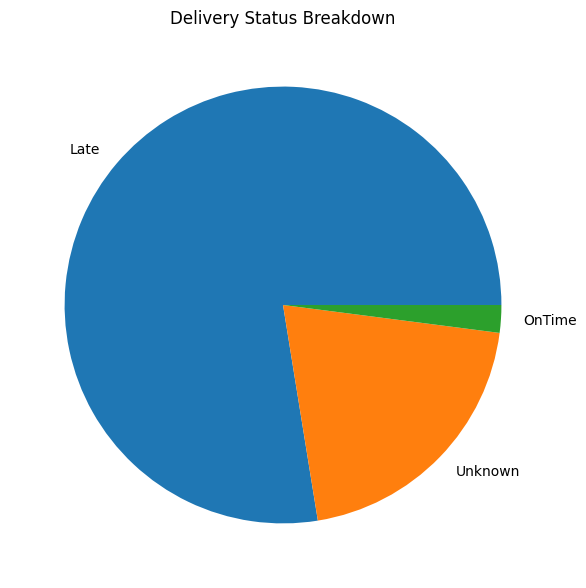

In [40]:
# Visualization 3: Delivery Status Count
plt.figure(figsize=(6,6))

df["DeliveryStatus"].value_counts().plot(kind="pie")

plt.title("Delivery Status Breakdown")

plt.ylabel("")

# adjust layout to make sure everything fits well
plt.tight_layout()

plt.show()

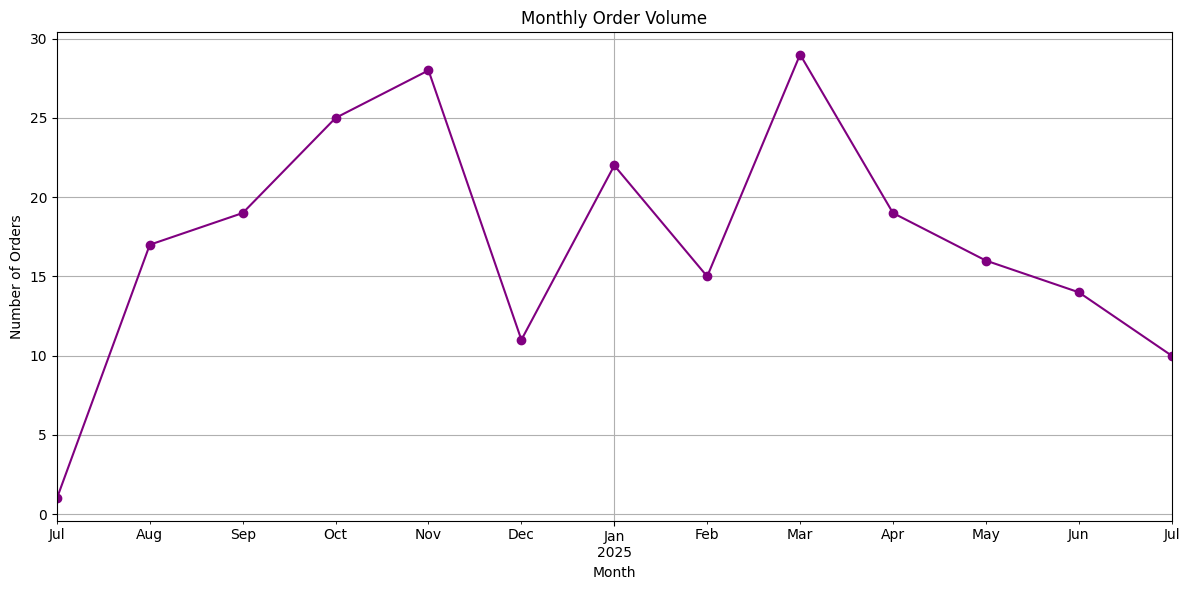

In [42]:
# Visualization 3: Monthly Order Volume
df["Months"] = df["OrderDate"].dt.to_period("M")

monthly_orders = df.groupby("Months").size()

plt.figure(figsize=(12,6))

monthly_orders.plot(kind= "line", marker="o", color="purple")

plt.title("Monthly Order Volume")

plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid()

plt.tight_layout()

plt.show()